# 2024 CITS4012 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

## Imports

In [1]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger_eng")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\marti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\marti\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\marti\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## Dataset Path




In [2]:
db_path = "dataset"

train_file = f"{db_path}/train.json"
test_file = f"{db_path}/test.json"
val_file = f"{db_path}/validation.json"

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [3]:
import json
import pprint
with open(train_file, "r") as fp:
    train = json.load(fp)
with open(val_file, "r") as fp:
    val = json.load(fp)
with open(test_file, "r") as fp:
    test = json.load(fp)

pprint.pprint({
    "dataset_length": len(train['premise']),
    "example": 0,
    "premise": train['premise']['0'],
    "hypothesis": train['hypothesis']['0'],
    "label": train['label']['0'],
})

{'dataset_length': 23088,
 'example': 0,
 'hypothesis': 'Earth rotates on its axis once times in one day.',
 'label': 'neutral',
 'premise': 'Pluto rotates once on its axis every 6.39 Earth days;'}


## Tokenization Config

The config class allows us to adjust the word tokenizations, allowing for the experimentation of different embeddings.
We have included the following options:

1. Lemmatization with a predefined lemmatizer, currently used being the WordNetLemmatizer
2. Stemming with a predefined Stemmer, currently used being the PorterStemmer.
3. Part of Speech tagging with nltk's *pos_tag* tagger.
4. Stopword removal, based on defined stopwords.
5. The assimilation of contradictions with identical meaning.

In [ ]:
from nltk.stem import WordNetLemmatizer, PorterStemmer, LancasterStemmer
from nltk import pos_tag

class Config:
    stem = False
    stemmer = PorterStemmer()
    lemmatize = True
    lemmatizer = WordNetLemmatizer()

    clean_text = True
    regex = r"[^\w\s]"

    postag = True
    postag_tagger = pos_tag

    lower = True

    index = True

    clean_stopwords = True
    stopwords = set(stopwords.words('english'))

    contradiction_dict = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have",
                    "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not",
                    "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did",
                    "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have",
                    "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have",
                    "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                    "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us",
                    "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have",
                    "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have",
                    "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not",
                    "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have",
                    "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have",
                    "so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                    "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                    "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not",
                    "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have",
                    "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have",
                    "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will",
                    "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have",
                    "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have",
                    "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                    "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}


## Tokenizer

The Tokenizer class cleans and adjusts any given text with a specific config. 
The *neutral* tag is defined as $0$, while the entails tag is defined as $1$.

In [5]:
class Tokenizer():
    def __init__(self, cfg: Config) -> None:
        self.cfg = cfg

        self.lemmatizer = cfg.lemmatizer
        self.stemmer = cfg.stemmer
        self.stop_words = cfg.stopwords

        self.postag_tagger = cfg.postag_tagger

        if getattr(cfg, "index", False):
            self.vocab = {
                "[PAD]": 0,
                "[UNK]": 1,
                "[CLS]": 2,
                "[SEP]": 3
            }
            self.idx2word = {idx: tok for tok, idx in self.vocab.items()}
            self.counter = 4
            self.freqs = {}
    
    def _add_to_vocab(self, tokens):
        ids = []
        for token in tokens:
            # update frequency
            if getattr(self.cfg, "train", False):
                self.freqs[token] = self.freqs.get(token, 0) + 1
                if token not in self.vocab:
                    self.vocab[token] = self.counter
                    self.idx2word[self.counter] = token
                    self.counter += 1
            ids.append(self.vocab.get(token, self.vocab["[UNK]"]))
        return ids

    def clean(self, sentence: str) -> list[str]:
        clean = {
            'tokens': [],
            'postag': [],
            'segments': [],
            "ids": []
        }
        tokens = [sentence]
        tokens = nltk.word_tokenize(sentence)
        
        if self.cfg.lemmatize:
            tokens = [self.lemmatizer.lemmatize(token) for token in tokens]

        if self.cfg.stem:
            tokens = [self.stemmer.stem(token) for token in tokens]

        if self.cfg.clean_text:
            tokens = [re.sub(self.cfg.regex, '', token.lower() if self.cfg.lower else token) for token in tokens]

        if self.cfg.contradiction_dict is not None:
            for token in tokens:
                for word, replacement in self.cfg.contradiction_dict.items():
                    token = token.replace(word, replacement)

        if self.cfg.clean_stopwords:
            tokens = [token for token in tokens if token and token not in self.stop_words]

        if self.cfg.postag:
            tokens_postag = pos_tag(tokens)
            tokens, pos_tags = zip(*tokens_postag) if tokens_postag else ([], [])
            clean['postag'] = pos_tags
            clean['tokens'] = tokens
        
        token_ids = None
        if getattr(self.cfg, "index", False):
            token_ids = self._add_to_vocab(tokens)
            clean['ids'] = token_ids

        return clean
    
    def clean_text(self, json):
        clean = {
            'premise': {},
            'premise_ids': {},
            'premise_postag': {},
            'hypothesis': {},
            'hypothesis_ids': {},
            'hypothesis_postag': {},
            'label': {}
        }

        for idx, key in enumerate(json['label'].keys()):
            premise_clean = self.clean(json['premise'][key])
            h_clean = self.clean(json['hypothesis'][key])

            p_tokens, p_postag, p_ids = premise_clean['tokens'], premise_clean['postag'], premise_clean['ids']
            h_tokens, h_postag, h_ids = h_clean['tokens'], h_clean['postag'], h_clean['ids']

            if len(p_tokens) == 0:
                print(f" Warning: Empty premise at index {idx} (key: {key}).")
            if len(h_tokens) == 0:
                print(f" Warning: Empty hypothesis at index {idx} (key: {key}).")
            

            clean['label'][idx] = 0 if 'neutral' in json['label'][key] else 1
            clean['premise'][idx] = p_tokens
            clean['premise_postag'][idx] = p_postag
            clean['premise_ids'][idx] = p_ids

            if len(p_tokens) != len(p_postag):
                raise ValueError(f"Mismatch in premise tokens and postag tags at index {idx} (key: {key}). len(p_tokens): {len(p_tokens)}, len(p_postag): {len(p_postag)}")
            clean['hypothesis'][idx] = h_tokens
            clean['hypothesis_postag'][idx] = h_postag
            clean['hypothesis_ids'][idx] = h_ids

        return clean
    

The train, validation and test datasets are then processed with the given config.

In [6]:
cfg = Config()
cfg.train = True
train_tokenizer = Tokenizer(cfg)
clean_train = train_tokenizer.clean_text(train)
# build vocab from train set, and use UNK for any unknown in val or test
VOCAB_SIZE = len(train_tokenizer.vocab)
cfg.train = False
test_tokenizer = Tokenizer(cfg)
clean_val = test_tokenizer.clean_text(val)
clean_test = test_tokenizer.clean_text(test)

Of note, there are 20344 different tokens in the training dataset.

In [7]:
VOCAB_SIZE

20344

The cleaned text is collated into a pandas Dataframe object for ease of use during training.

In [8]:
import pandas as pd

# For training set
train_df = pd.DataFrame({
    "label": clean_train["label"],
    "premise": clean_train["premise"],
    "hypothesis": clean_train["hypothesis"],
    "premise_postag": clean_train["premise_postag"],
    "hypothesis_postag": clean_train["hypothesis_postag"],
    "premise_ids": clean_train.get("premise_ids"),      # add token IDs
    "hypothesis_ids": clean_train.get("hypothesis_ids")
})

# Validation set
val_df = pd.DataFrame({
    "label": clean_val["label"],
    "premise": clean_val["premise"],
    "hypothesis": clean_val["hypothesis"],
    "premise_postag": clean_val["premise_postag"],
    "hypothesis_postag": clean_val["hypothesis_postag"],
    "premise_ids": clean_val.get("premise_ids"),
    "hypothesis_ids": clean_val.get("hypothesis_ids")
})

# Test set
test_df = pd.DataFrame({
    "label": clean_test["label"],
    "premise": clean_test["premise"],
    "hypothesis": clean_test["hypothesis"],
    "premise_postag": clean_test["premise_postag"],
    "hypothesis_postag": clean_test["hypothesis_postag"],
    "premise_ids": clean_test.get("premise_ids"),
    "hypothesis_ids": clean_test.get("hypothesis_ids")
})

train_df.head(5)


,label,premise,hypothesis,premise_postag,hypothesis_postag,premise_ids,hypothesis_ids
0,0,"(pluto, rotates, axis, every, 639, earth, day)","(earth, rotates, axis, time, one, day)","(NN, NNS, VBP, DT, CD, NN, NN)","(NN, VBZ, JJ, NN, CD, NN)","[4, 5, 6, 7, 8, 9, 10]","[9, 5, 6, 11, 12, 10]"
1,1,"(glenn, per, day, earth, rotates, axis)","(earth, rotates, axis, time, one, day)","(NNS, IN, NN, NN, VBZ, IN)","(NN, VBZ, JJ, NN, CD, NN)","[13, 14, 10, 9, 5, 6]","[9, 5, 6, 11, 12, 10]"
2,0,"(geyser, periodic, gush, hot, water, surface, ...","(surface, sun, much, hotter, almost, anything,...","(NN, JJ, NN, JJ, NN, NN, NN)","(NN, NN, JJ, NN, RB, NN, JJ)","[15, 16, 17, 18, 19, 20, 9]","[20, 21, 22, 23, 24, 25, 9]"
3,1,"(facts, liquid, water, droplet, changed, invis...","(evaporation, responsible, changing, liquid, w...","(NNS, JJ, NN, NN, VBD, JJ, NN, NN, NN, VBN, NN)","(NN, JJ, VBG, JJ, NN, NN, NN)","[26, 27, 19, 28, 29, 30, 19, 31, 32, 33, 34]","[34, 35, 36, 27, 19, 19, 31]"
4,1,"(comparison, earth, rotates, axis, per, day, r...","(earth, rotates, axis, time, one, day)","(NN, NN, VBZ, JJ, IN, NN, VBZ, IN, NN, IN, NN)","(NN, VBZ, JJ, NN, CD, NN)","[37, 9, 5, 6, 14, 10, 38, 39, 21, 14, 40]","[9, 5, 6, 11, 12, 10]"


## Dataset Visualisation

By visualising the dataset, we can see that the training and test sets are imbalanced, with the validation set perfectly balanced.

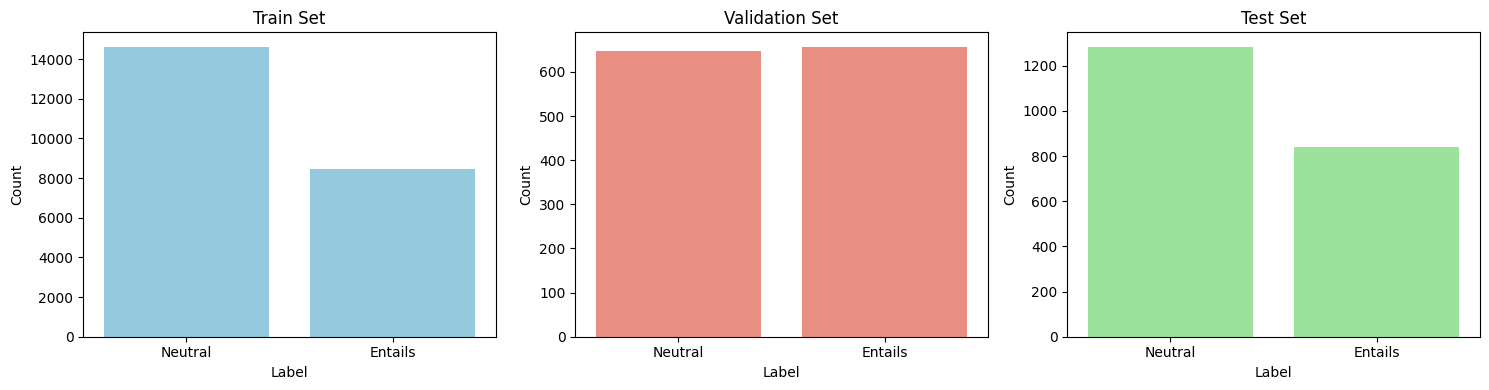

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

splits = [('Train', train_df), ('Validation', val_df), ('Test', test_df)]
colors = ['skyblue', 'salmon', 'lightgreen']  # one color per split

plt.figure(figsize=(15,4))

for i, ((name, df), color) in enumerate(zip(splits, colors), 1):
    plt.subplot(1, 3, i)
    counts = df['label'].value_counts().sort_index()
    sns.barplot(x=['Neutral', 'Entails'], y=counts.values, color=color)
    plt.title(f"{name} Set")
    plt.xlabel("Label")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

We can also see the maximum and minimum lengths of the training dataset.
The premises ranges from 0-6686, with the hypotheses ranging from 2-22.

In [ ]:
import pandas as pd

def premise_hypothesis_stats(df):
    """
    Compute min, max, and average token lengths for premise and hypothesis.
    """
    premise_lengths = df['premise_ids'].apply(len)
    hypothesis_lengths = df['hypothesis_ids'].apply(len)
    
    stats = {
        'premise': {
            'min': premise_lengths.min(),
            'max': premise_lengths.max(),
            'avg': premise_lengths.mean()
        },
        'hypothesis': {
            'min': hypothesis_lengths.min(),
            'max': hypothesis_lengths.max(),
            'avg': hypothesis_lengths.mean()
        }
    }
    return stats

stats = premise_hypothesis_stats(train_df)
print("Premise: min={}, max={}, avg={:.2f}".format(
    stats['premise']['min'], stats['premise']['max'], stats['premise']['avg']
))
print("Hypothesis: min={}, max={}, avg={:.2f}".format(
    stats['hypothesis']['min'], stats['hypothesis']['max'], stats['hypothesis']['avg']
))


Premise: min=0, max=6686, avg=10.76
Hypothesis: min=2, max=22, avg=6.93


## Word Embedding Generation
The word embeddings are generated with Gensim's Word2Vec model.

In [12]:
from gensim.models import Word2Vec
sentences = list(clean_train['premise'].values()) + list(clean_train['hypothesis'].values())
embed_model = Word2Vec(sentences=sentences, vector_size=200, window=5, min_count=3, workers=2, sg=1)

## Part of Speech Tagging 
The part of speech tags generated from the tokenizer are assigned an embedding index, 
from $0-n$, where n is the total amount of different POS tags.
It is then stored into a dictionary object in order for later use. 
As the pos tags are based on the training data, unseen POS tags are assigned as unknown in order to account for other datasets. (\<UNK>)

In [ ]:
# Build postag2idx from training set only
all_postags = set()
for postag_list in train_df['premise_postag']:
    all_postags.update(postag_list)
for postag_list in train_df['hypothesis_postag']:
    all_postags.update(postag_list)

postag2idx = {postag: i for i, postag in enumerate(sorted(all_postags))}
postag2idx['<UNK>'] = len(postag2idx)
num_postag_tags = len(postag2idx)

len(postag2idx), list(postag2idx.items())[:5]

(35, [('$', 0), ("''", 1), ('CC', 2), ('CD', 3), ('DT', 4)])

Thus an encoding function is provided to get the corresponding part of speech tag index.

In [14]:
def encode_postag(postag_list, postag2idx):
    return [postag2idx.get(postag, postag2idx['<UNK>']) for postag in postag_list]

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## PyTorch Dataset

In order to facilitate model training, a pytorch dataset is constructed to allow for batch training of models.
The dataset, defined as `nliDataset`, on access returns a dictionary containing all relevant information.  
Each key in the dictionary corresponds to a component used during training:

1. **p_embed**: Premise Word Embedding tensor, of shape (sequence_length, embedding_dimension).  
2. **h_embed**: Hypothesis Word Embedding tensor, of shape (sequence_length, embedding_dimension).  
3. **label**: Ground-truth label for the NLI pair, a 0 or 1.  
4. **premise_postag**: Part of Speech Tags for premise.  
5. **hypothesis_postag**: Part of Speech Tags for hypothesis.  
6. **premise_segments**: Segment information for the premise, applying an ID of 0 to the premise.  
7. **hypothesis_segments**: Segment embeddings for the hypothesis, applying an ID of 1 to the premise.


In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset,  DataLoader

class nliDataset(Dataset):
  def __init__(self, df, embed_model, postag2idx=postag2idx, encode_postag=encode_postag):
    self.df = df
    self.embed_model = embed_model
    self.postag_encode = encode_postag
    self.postag2idx = postag2idx

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    premise = self.df["premise"].iloc[index]
    hypothesis = self.df["hypothesis"].iloc[index]
    
    p_embed = np.array([
        self.embed_model.wv[word] if word in self.embed_model.wv else np.zeros(self.embed_model.vector_size)
        for word in premise
    ])
    h_embed = np.array([
        self.embed_model.wv[word] if word in self.embed_model.wv else np.zeros(self.embed_model.vector_size)
        for word in hypothesis
    ])


    if len(p_embed) == 0:
        p_embed = np.zeros((1, self.embed_model.vector_size))
    if len(h_embed) == 0:
        h_embed = np.zeros((1, self.embed_model.vector_size))
    

    # Part of speech tagging
    premise_postag = self.df["premise_postag"].iloc[index]
    hypothesis_postag = self.df["hypothesis_postag"].iloc[index]

    premise_postag = self.postag_encode(premise_postag, self.postag2idx)
    hypothesis_postag = self.postag_encode(hypothesis_postag, self.postag2idx)

    if len(p_embed) == 1 and len(premise) == 0:
        premise_postag = [self.postag2idx['<UNK>']]
    if len(h_embed) == 1 and len(hypothesis) == 0:
        hypothesis_postag = [self.postag2idx['<UNK>']]

    if len(premise_postag) != len(p_embed):
        raise ValueError(f"Mismatch in lengths at index {index}. premise_postag length: {len(premise_postag)}, p_embed length: {len(p_embed)}")
    if len(hypothesis_postag) != len(h_embed):
        raise ValueError(f"Mismatch in lengths at index {index}. hypothesis_postag length: {len(hypothesis_postag)}, h_embed length: {len(h_embed)}")

    label = int(self.df["label"].iloc[index])
    p_embed = torch.tensor(p_embed, dtype=torch.float32)
    premise_postag = torch.tensor(premise_postag, dtype=torch.long)

    h_embed = torch.tensor(h_embed, dtype=torch.float32)
    hypothesis_postag = torch.tensor(hypothesis_postag, dtype=torch.long)

    label = torch.tensor(label, dtype=torch.float32)

    p_ids = self.df["premise_ids"].iloc[index]
    h_ids = self.df["hypothesis_ids"].iloc[index]

    p_seg = [0] * len(p_ids)  # Premise = segment 0
    h_seg = [1] * len(h_ids)

    p_ids = torch.tensor(p_ids, dtype=torch.long)
    h_ids = torch.tensor(h_ids, dtype=torch.long)
    sample = {
        "p_embed": p_embed,
        "h_embed": h_embed,
        "label": label,
        "p_postag": premise_postag,
        "h_postag": hypothesis_postag,
        "p_segments": torch.tensor(p_seg, dtype=torch.long),
        "h_segments": torch.tensor(h_seg, dtype=torch.long),
        "p_ids": p_ids,
        "h_ids": h_ids
    }

    return sample


In [110]:
db = nliDataset(train_df, embed_model)
sample = db.__getitem__(0)
sample['p_embed'].shape, sample['h_embed'].shape, sample['label'], sample['p_postag'], sample['h_postag'], sample['p_ids'], sample['h_ids']

(torch.Size([7, 200]),
 torch.Size([6, 200]),
 tensor(0.),
 tensor([12, 14, 28,  4,  3, 12, 12]),
 tensor([12, 29,  8, 12,  3, 12]),
 tensor([ 4,  5,  6,  7,  8,  9, 10]),
 tensor([ 9,  5,  6, 11, 12, 10]))

### The Collate Function

In order to use variable length inputs for batch training, a padding sequence must be applied for consistent batch dimensions.

In [111]:
import torch
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    
    p_embeds = [item["p_embed"] for item in batch]
    h_embeds = [item["h_embed"] for item in batch]

    p_postag_idx = [item["p_postag"] for item in batch]
    h_postag_idx = [item["h_postag"] for item in batch]

    p_segments = [item["p_segments"] for item in batch]
    h_segments = [item["h_segments"] for item in batch]

    p_ids = [item["p_ids"] for item in batch]
    h_ids = [item["h_ids"] for item in batch]

    labels = [item["label"] for item in batch]

    p_padded = pad_sequence(p_embeds, batch_first=True) 
    h_padded = pad_sequence(h_embeds, batch_first=True) 
    p_postag_padded = pad_sequence(p_postag_idx, batch_first=True, padding_value=postag2idx['<UNK>'])
    h_postag_padded = pad_sequence(h_postag_idx, batch_first=True, padding_value=postag2idx['<UNK>'])

    labels = torch.stack(labels)


    p_ids_padded = pad_sequence(p_ids, batch_first=True, padding_value=0)  # 0 = PAD
    h_ids_padded = pad_sequence(h_ids, batch_first=True, padding_value=0)

    p_seg = pad_sequence(p_segments, batch_first=True, padding_value=0)  # 0 = PAD
    h_seg = pad_sequence(h_segments, batch_first=True, padding_value=0)  # 0 = PAD

    plengths = torch.tensor([x.shape[0] for x in p_embeds])
    hlengths = torch.tensor([x.shape[0] for x in h_embeds])

    if p_postag_padded.shape[1] != p_padded.shape[1]:
        raise ValueError("Mismatch in padded lengths between p_postag and p_embed.")\
    
    return {
        "p_embed": p_padded,
        "h_embed": h_padded,
        "p_postag": p_postag_padded,
        "h_postag": h_postag_padded,
        "label": labels,
        "p_lengths": plengths,
        "h_lengths": hlengths,
        "p_segments": p_seg,
        "h_segments": h_seg,
        "p_ids": p_ids_padded,
        "h_ids": h_ids_padded
    }


train_db = nliDataset(train_df, embed_model=embed_model)
trainloader = DataLoader(train_db, batch_size=8, shuffle=False, collate_fn=collate_fn)
val_db = nliDataset(val_df, embed_model=embed_model)
valloader = DataLoader(val_db, batch_size=8, shuffle=False, collate_fn=collate_fn)
test_db = nliDataset(test_df, embed_model=embed_model)
testloader = DataLoader(test_db, batch_size=8, shuffle=False, collate_fn=collate_fn)

len(trainloader), len(valloader), len(testloader)

sample = next(iter(trainloader))
sample['p_embed'].shape, sample['h_embed'].shape, sample['label'], sample['p_postag'].shape, sample['h_postag'].shape, sample['p_lengths'], sample['h_lengths']

(torch.Size([8, 17, 200]),
 torch.Size([8, 10, 200]),
 tensor([0., 1., 0., 1., 1., 0., 0., 0.]),
 torch.Size([8, 17]),
 torch.Size([8, 10]),
 tensor([ 7,  6,  7, 11, 11, 17, 10,  9]),
 tensor([ 6,  6,  7,  7,  6,  8,  8, 10]))

## Task

The generic training task for a NLI purpostages is defined here. The task allows for different models, and forward functions to produce classification outputs, with configurable weighted random sampling as well.

In [ ]:
from collections import Counter
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

class Task():
  def __init__(self, model, 
                train_df, 
                val_df,
                test_df,
                save_path, 
                collate_fn=collate_fn, 
                optimizer=None,
                scheduler=None,
                loss_fn=None,
                device="cpu", 
                batch_size=16, 
                weighted_sampling=True,
                forward_func=None,
                shuffle=False) -> None:

    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df
    self.optimizer = optimizer
    self.loss_fn = loss_fn
    self.batch_size = batch_size

    self.forward = forward_func if forward_func is not None else model.forward
    self.save_path = save_path

    if weighted_sampling:
      labels = train_df['label'].values
      class_counts = Counter(labels)
      num_samples = len(labels)
      class_weights = {cls: num_samples/count for cls, count in class_counts.items()}
      sample_weights = [class_weights[label] for label in labels]
      sampler = WeightedRandomSampler(sample_weights, num_samples=num_samples, replacement=True)
      shuffle=False
    else:
      sampler = None
    
    train_db = nliDataset(train_df, embed_model=embed_model)
    val_db = nliDataset(val_df, embed_model=embed_model)
    test_db = nliDataset(test_df, embed_model=embed_model) 

    self.train_loader = DataLoader(train_db, batch_size=batch_size, sampler=sampler, shuffle=shuffle, collate_fn=collate_fn)
    self.val_loader = DataLoader(val_db, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    self.test_loader = DataLoader(test_db, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    self.scheduler = scheduler

    self.model = model
    if model is not None:
       self.model = model.to(device)
    self.device = device

    self.losses = {
      "train": [],
      "val": []
    }

  def train_epoch(self, verbose=True):
    self.model.train()
    epoch_loss = 0
    for batch in tqdm(self.train_loader, total=len(self.train_loader), desc="Training", disable=(not verbose)):
        labels = batch["label"]
        labels = labels.float().to(self.device)
        

        outputs = self.forward(batch, self.model, self.device)
        loss = self.loss_fn(outputs, labels)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(self.train_loader)
    return epoch_loss

  def validate_epoch(self, verbose=True):
    self.model.eval()
    with torch.no_grad():
        val_loss = 0
        correct = 0
        total = 0

        for batch in tqdm(self.val_loader, total=len(self.val_loader), desc="Validating", disable=(not verbose)):
            
          labels = batch["label"]
          labels = labels.to(self.device)

          outputs = self.forward(batch, self.model, self.device)
          loss = self.loss_fn(outputs, labels)
          val_loss += loss.item()


          predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze()  
          correct += (predicted == labels.squeeze()).sum().item()

          total += labels.size(0)

        val_loss /= len(self.val_loader)
        accuracy = correct / total
    return val_loss, accuracy

  def fit(self, epochs=10, restore_best=True, patience=3, verbose=True):
    count = 0
    bect_val_acc = 0
    for epoch in range(epochs):
        train_loss = self.train_epoch(verbose=verbose)
        val_loss, val_acc = self.validate_epoch(verbose=verbose)

        self.losses["train"].append(train_loss)
        self.losses["val"].append(val_loss)

        if verbose == True:
          print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > bect_val_acc:
            bect_val_acc = val_acc
            count = 0

            if self.save_path is not None:
              torch.save(self.model.state_dict(), self.save_path)

            if verbose == True:
              print(f"Model saved to {self.save_path}")
        if self.scheduler is not None:
          self.scheduler.step(val_acc)
        count += 1
        if count >= patience and verbose == True:
            print(f"No improvement in validation accuracy for {patience} consecutive epochs. Early stopping.")
            break
    print("Training complete.")
    if restore_best and self.save_path is not None:
      print("Restoring best model weights.")
      self.model.load_state_dict(torch.load(self.save_path))

  def plot_losses(self):
    plt.figure(figsize=(10,5))
    plt.plot(self.losses["train"], label="Train Loss")
    plt.plot(self.losses["val"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss over Epochs")
    plt.legend()
    plt.show()


  def visualize_predictions(self, num_samples=5):
    """
    Visualizes predictions vs targets for a few random samples from the test set.
    Args:
        num_samples: Number of random examples to show
    """
    self.model.eval()
    all_samples = []

    with torch.no_grad():
        for batch in self.test_loader:
            labels = batch["label"].to(self.device)
            outputs = self.forward(batch, self.model, self.device)
            probs = torch.sigmoid(outputs.squeeze())

            for prob, label in zip(probs, labels):
                pred_label = int(prob > 0.5)
                all_samples.append((prob.item(), pred_label, int(label.item())))

    samples_to_show = random.sample(all_samples, min(num_samples, len(all_samples)))

    print(f"{'Pred Prob':>10} | {'Pred Label':>10} | {'Target':>6}")
    print("-"*32)
    for prob, pred, target in samples_to_show:
        print(f"{prob:10.3f} | {pred:10} | {target:6}")

  def evaluate(self):
        """
        Evaluate the model on the test set and return classification metrics.
        Returns:
            dict: Contains accuracy, precision, recall, f1, confusion matrix, and full report
        """
        self.model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in tqdm(self.test_loader, total=len(self.test_loader), desc="Evaluating"):
                outputs = self.forward(batch, self.model, self.device)

                labels = batch["label"].to(self.device)
                probs = torch.sigmoid(outputs.squeeze())
                preds = (probs > 0.5).long()

                all_preds.extend(preds.cpu().numpy().tolist())
                all_labels.extend(labels.cpu().numpy().tolist())

        # Compute metrics
        metrics = {
            "accuracy": accuracy_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds, zero_division=0),
            "recall": recall_score(all_labels, all_preds, zero_division=0),
            "f1": f1_score(all_labels, all_preds, zero_division=0),
            "confusion_matrix": confusion_matrix(all_labels, all_preds).tolist(),
            "classification_report": classification_report(all_labels, all_preds, zero_division=0, output_dict=True)
        }

        return metrics
  

  def visualize_metrics(self, metrics_dict, class_names=['Neutral', 'Entails']):
      """
      Visualize metrics, confusion matrix, and classification report from a precomputed metrics dictionary.

      Args:
          metrics_dict (dict): Dictionary containing 'accuracy', 'precision', 'recall', 'f1',
                              'confusion_matrix' (as list of lists), and 'classification_report' (as dict)
          class_names (list, optional): Class names for confusion matrix
      """
      print("=== Overall Metrics ===")
      for key in ["accuracy", "precision", "recall", "f1"]:
          print(f"{key.capitalize():<10}: {metrics_dict[key]:.4f}")
      print("\n")

      cm = metrics_dict["confusion_matrix"]
      plt.figure(figsize=(6, 5))
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=class_names, yticklabels=class_names)
      plt.xlabel('Predicted')
      plt.ylabel('Actual')
      plt.title('Confusion Matrix')
      plt.show()

      report_dict = metrics_dict["classification_report"]
      print("=== Classification Report ===\n")
      display(report_dict)  

      plt.figure(figsize=(5, 4))
      main_metrics = ["accuracy", "precision", "recall", "f1"]
      values = [metrics_dict[m] for m in main_metrics]
      sns.barplot(x=main_metrics, y=values, palette="viridis")
      plt.ylim(0, 1)
      plt.title("Main Metrics")
      plt.show()


## Bert Inspired Model

The BERT model from Devlin et al's 2018 paper implements a summation embedding of token, segment and postagition. 
It is an encoder only style natural language processing model.

For the BERT inspired model, a consistent sequence length and size is required, thus everysample is then padded or truncated to the required sequence dimensions.
This is done by either randomly truncating from the front or back, or just padding to length.

In [ ]:
import torch

def format_ids(
    premise_ids,
    hypothesis_ids,
    p_postags=None,
    h_postags=None,
    cls_id=2,
    sep_id=3,
    pad_id=0,
    cls_pos_id=0,  # POS tag for [CLS]
    sep_pos_id=0,  # POS tag for [SEP]
    pad_pos_id=0,  # POS tag for [PAD]
    max_len=None
):
    """
    Convert padded premise/hypothesis IDs into BERT-style input:
        [CLS] premise_ids [SEP] hypothesis_ids [SEP]
    
    Args:
        premise_ids: LongTensor (batch, p_len)
        hypothesis_ids: LongTensor (batch, h_len)
        p_postags: LongTensor (batch, p_len) - POS tags for premise tokens
        h_postags: LongTensor (batch, h_len) - POS tags for hypothesis tokens
        cls_id: ID for [CLS] token
        sep_id: ID for [SEP] token
        pad_id: ID for [PAD] token
        cls_pos_id: POS tag ID for [CLS] token
        sep_pos_id: POS tag ID for [SEP] token
        pad_pos_id: POS tag ID for [PAD] token
        max_len: optional maximum sequence length (truncate if needed)
    
    Returns:
        input_ids: LongTensor (batch, seq_len)
        segment_ids: LongTensor (batch, seq_len)
        attention_mask: FloatTensor (batch, seq_len)
        pos_ids: LongTensor (batch, seq_len) - only if p_postags and h_postags provided
    """
    batch_size = premise_ids.size(0)
    device = premise_ids.device
    use_pos = p_postags is not None and h_postags is not None
    
    input_ids_list = []
    segment_ids_list = []
    attention_masks_list = []
    pos_ids_list = [] if use_pos else None

    for i in range(batch_size):
        p = premise_ids[i]
        h = hypothesis_ids[i]

        # Remove trailing PADs
        p_len = (p != pad_id).sum().item()
        h_len = (h != pad_id).sum().item()
        p = p[:p_len]
        h = h[:h_len]

        # BERT-style concat: [CLS] + premise + [SEP] + hypothesis + [SEP]
        seq = torch.cat([
            torch.tensor([cls_id], dtype=torch.long, device=device),
            p,
            torch.tensor([sep_id], dtype=torch.long, device=device),
            h,
            torch.tensor([sep_id], dtype=torch.long, device=device)
        ])

        # Handle POS tags if provided
        if use_pos:
            p_pos = p_postags[i][:p_len]
            h_pos = h_postags[i][:h_len]
            
            pos_seq = torch.cat([
                torch.tensor([cls_pos_id], dtype=torch.long, device=device),  # [CLS]
                p_pos,                                                        # premise POS
                torch.tensor([sep_pos_id], dtype=torch.long, device=device),  # [SEP]
                h_pos,                                                          # hypothesis POS
                torch.tensor([sep_pos_id], dtype=torch.long, device=device)   # [SEP]
            ])

        if max_len is not None and seq.size(0) > max_len:
            seq = seq[:max_len]
            if use_pos:
                pos_seq = pos_seq[:max_len]

        seg_len = seq.size(0)
        seg_ids = torch.zeros(seg_len, dtype=torch.long, device=device)
        premise_end = 1 + p_len + 1  # CLS + premise + SEP
        if premise_end < seg_len:
            seg_ids[premise_end:] = 1

        # Pad if needed
        if max_len is not None and seg_len < max_len:
            pad_len = max_len - seg_len
            seq = torch.cat([seq, torch.full((pad_len,), pad_id, dtype=torch.long, device=device)])
            seg_ids = torch.cat([seg_ids, torch.full((pad_len,), 0, dtype=torch.long, device=device)])
            if use_pos:
                pos_seq = torch.cat([pos_seq, torch.full((pad_len,), pad_pos_id, dtype=torch.long, device=device)])

        attn_mask = (seq != pad_id).float()

        input_ids_list.append(seq)
        segment_ids_list.append(seg_ids)
        attention_masks_list.append(attn_mask)
        if use_pos:
            pos_ids_list.append(pos_seq)

    input_ids = torch.stack(input_ids_list)
    segment_ids = torch.stack(segment_ids_list)
    attention_mask = torch.stack(attention_masks_list)

    if use_pos:
        pos_ids = torch.stack(pos_ids_list)
        return input_ids, segment_ids, attention_mask, pos_ids
    else:
        return input_ids, segment_ids, attention_mask


batch = next(iter(trainloader))
p_ids = batch["p_ids"]
h_ids = batch["h_ids"]
p_pos = batch["p_postag"]
h_pos = batch["h_postag"]
input_ids, seg_ids, attn_mask = format_ids(
    p_ids, h_ids,
    max_len=20
)
input_ids.shape, seg_ids.shape, attn_mask.shape

(torch.Size([8, 20]), torch.Size([8, 20]), torch.Size([8, 20]))

In [ ]:
batch = next(iter(trainloader))
p_ids = batch['p_ids']
h_ids = batch['h_ids']
padded_seqs, segments, attn_masks = format_ids(p_ids, h_ids, max_len=20)
padded_seqs.shape, segments.shape, attn_masks.shape


tensor([ 4,  5,  6,  7,  8,  9, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]) tensor([ 9,  5,  6, 11, 12, 10,  0,  0,  0,  0])
torch.Size([8, 20]) torch.Size([8, 20]) torch.Size([8, 20])


The BERT model differs from traditional recurrent networks, as it uses a fixed size input. The model uses a separation token between the premise and hypothesis, with padding / truncation used to constrain
the samples to a required length. This consistent input size is then used in a BERT-style embedding. Traditional BERT uses positional encoding, segment encoding, and then word encoding. For the purposes of this
research, we have elected to use Part of speech tag encoding in lieu of positonal encoding.

In [115]:
import torch
import torch.nn as nn

class BERTEmbedding(nn.Module):
    def __init__(self, vocab_size, n_segments, max_len, embed_dim, dropout, postag_vocab_size=num_postag_tags):
        super().__init__()
        # Initialize CLS token with Xavier/Glorot initialization instead of randn
        
        # Word embeddings
        self.word_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # Assuming 0 is PAD
        
        # Segment embeddings (usually just 2 segments)
        self.seg_embed = nn.Embedding(n_segments, embed_dim)
        self.postags_embed = nn.Embedding(postag_vocab_size, embed_dim, padding_idx=0)
        self.layer_norm = nn.LayerNorm(embed_dim, eps=1e-12)
        
        self.drop = nn.Dropout(dropout)
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.word_embed.weight, mean=0, std=0.02)
        nn.init.normal_(self.seg_embed.weight, mean=0, std=0.02)
        
        if self.word_embed.padding_idx is not None:
            self.word_embed.weight.data[self.word_embed.padding_idx].zero_()

    def forward(self, x, seg, pos_tags):
        
        x = self.word_embed(x)  # (batch, seq_len, embed_dim)

        seg_embed = self.seg_embed(seg)
        postag_embed = self.postags_embed(pos_tags)  # (batch, seq_len, embed_dim)


        embeddings = x + seg_embed + postag_embed
        
        embeddings = self.layer_norm(embeddings)
        embeddings = self.drop(embeddings)
        return embeddings


The BERT net itself uses a transformer encoder with multi-headed attention layers to produce its output.

In [ ]:
class BERTNet(nn.Module):
    def __init__(self, n_segments, max_len, embed_dim, n_layers, attn_heads, dropout, vocab_size=VOCAB_SIZE):
        super().__init__()
        self.embedding = BERTEmbedding(vocab_size,n_segments, max_len, embed_dim, dropout)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(embed_dim, attn_heads, embed_dim*4, batch_first=True),
            num_layers=n_layers
        )

        self.fc = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),  # Keep dimensionality first
            nn.Tanh(),  # BERT uses Tanh in pooler
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x, seg, pos_tags, attention_mask=None):
        x = self.embedding(x, seg, pos_tags)
        if attention_mask is not None:
            key_padding_mask = attention_mask == 0
        else:
            key_padding_mask = None

        out = self.encoder(x, src_key_padding_mask=key_padding_mask)


        out = torch.mean(out, dim=1)
        logits = self.fc(out).squeeze(-1)
        return logits


In [ ]:
bert_model = BERTNet(
    n_segments=2,
    max_len=20,
    embed_dim=300,
    n_layers=2,
    attn_heads=4,
    dropout=0.3,
    vocab_size=VOCAB_SIZE
)

def bert_forward(batch, model, device, max_len=20):
    p_ids = batch["p_ids"]
    h_ids = batch["h_ids"]
    p_postag = batch["p_postag"]
    h_postag = batch["h_postag"]

    x, seg, attn_mask, pos_ids = format_ids(
        p_ids, h_ids,
        p_postags=p_postag,
        h_postags=h_postag,
        max_len=max_len
    )


    x = x.to(device)
    seg = seg.to(device)
    attn_mask = attn_mask.to(device)
    pos_ids = pos_ids.to(device)

    outputs = model(x, seg, pos_ids, attention_mask=attn_mask)
    return outputs


In [23]:
optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=10, factor=0.5
) 

bert_task = Task(
    model=bert_model,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    save_path="bert_nli.pth",
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=nn.BCEWithLogitsLoss(),
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=64,
    weighted_sampling=True,
    forward_func=bert_forward
)

In [ ]:
bert_task.fit(epochs=100, patience=10, restore_best=True, verbose=True)

In [ ]:
m = bert_task.evaluate()
bert_task.visualize_metrics(m)

Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]c:\Natural-Language-Processing\venv\Lib\site-packages\torch\nn\modules\transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Evaluating: 100%|██████████| 34/34 [00:01<00:00, 25.24it/s]


In [26]:
m

{'accuracy': 0.4830667920978363,
 'precision': 0.41540487162606976,
 'recall': 0.7494061757719715,
 'f1': 0.5345192714951292,
 'confusion_matrix': [[396, 888], [211, 631]],
 'classification_report': {'0.0': {'precision': 0.6523887973640856,
   'recall': 0.308411214953271,
   'f1-score': 0.4188260179799048,
   'support': 1284.0},
  '1.0': {'precision': 0.41540487162606976,
   'recall': 0.7494061757719715,
   'f1-score': 0.5345192714951292,
   'support': 842.0},
  'accuracy': 0.4830667920978363,
  'macro avg': {'precision': 0.5338968344950776,
   'recall': 0.5289086953626213,
   'f1-score': 0.476672644737517,
   'support': 2126.0},
  'weighted avg': {'precision': 0.5585315699551442,
   'recall': 0.4830667920978363,
   'f1-score': 0.464646205872576,
   'support': 2126.0}}}

## C-LSTM 

A NLP C-LSTM model, based off of Zhou et al's 2015 paper *A C-LSTM Neural Network for Text Classification* using a 1-dimensional convolutional network was implemented to.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class CLSTM(nn.Module):
    def __init__(self, embed_dim, hidden_size=128, n_layers=1, dropout=0.1, postag_vocab_size=None, postag_emb_dim=16, bidirectional=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers

        # Optional POS embeddings
        if postag_vocab_size:
            self.postag_embedding = nn.Embedding(postag_vocab_size, postag_emb_dim)
        else:
            self.postag_embedding = None

        combined_input_size = embed_dim + (postag_emb_dim if postag_vocab_size else 0)

        # Convolution to get local context per token
        self.convs = nn.ModuleList([
            nn.Conv1d(combined_input_size, hidden_size, kernel_size=k, padding=k//2)
            for k in [3, 5, 7]
        ])

        # BiLSTM to capture sequential dependencies
        self.encoder = nn.LSTM(hidden_size * len([3,5,7]), hidden_size, num_layers=n_layers,
                               batch_first=True, bidirectional=True)

        # Classifier
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2 * (2 if bidirectional else 1), 32),  # 2*hidden for BiLSTM, *2 for premise+hypothesis
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward_sequence(self, x, lengths, postag_idx=None):
        # Add POS embeddings if provided
        if self.postag_embedding is not None and postag_idx is not None:
            postag_emb = self.postag_embedding(postag_idx)
            x = torch.cat([x, postag_emb], dim=-1)  # (B, L, embed+postag)

        # Conv expects (B, C_in, L)
        conv_in = x.transpose(1, 2)
        conv_outs = [F.relu(conv(conv_in)).transpose(1, 2) for conv in self.convs]
        conv_out = torch.cat(conv_outs, dim=-1)  # (B, L, hidden*len(kernels))

        # Pack for LSTM
        packed_x = pack_padded_sequence(conv_out, lengths.cpu(), batch_first=True, enforce_sorted=False)
        lstm_out, _ = self.encoder(packed_x)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)  # (B, L, 2*hidden)

        # Pooling across sequence length
        pooled = torch.stack([lstm_out[i, :lengths[i]].mean(0) for i in range(len(lengths))])
        return pooled

    def forward(self, p_embed, h_embed, p_lengths, h_lengths, p_postag=None, h_postag=None):
        p_vec = self.forward_sequence(p_embed, p_lengths, p_postag)
        h_vec = self.forward_sequence(h_embed, h_lengths, h_postag)

        combined = torch.cat([p_vec, h_vec], dim=-1)
        logits = self.fc(combined).squeeze(-1)
        return logits


The C-LSTM model is defined here.

In [120]:
c_lstm = CLSTM(
    embed_dim=embed_model.vector_size,
    hidden_size=32
)


The forward function for the C-LSTM is defined here.

In [ ]:
def clstm_forward(batch, model, device):
    p_embed = batch["p_embed"].to(device)
    h_embed = batch["h_embed"].to(device)

    p_lengths = batch["p_lengths"]
    h_lengths = batch["h_lengths"]
    premise_postag = batch["p_postag"]
    hypothesis_postag = batch["h_postag"]

    outputs = model(p_embed, h_embed, p_lengths, h_lengths, premise_postag, hypothesis_postag)
    return outputs

The adam optimizer with weight decay (L2 regularization) alongside a learning rate scheduler is applied.

In [126]:
optimizer = torch.optim.Adam(c_lstm.parameters(), lr=0.001,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

In [ ]:
cnn_task = Task(
    model=c_lstm,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    save_path="c_lstm.pth",
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=nn.BCEWithLogitsLoss(),
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=48,
    weighted_sampling=True,
    forward_func=clstm_forward
)

In [ ]:
cnn_task.fit(epochs=100, patience=5, verbose=False, restore_best=True)

Training:   6%|▌         | 29/481 [00:02<00:33, 13.68it/s]


KeyboardInterrupt: 

## Twin LSTM
A simple encoder-decoder style LSTM network is implemented, using the final decoder output with cross attention to the premise


### Attention

The Attention module implements 5 styles of attention, for a later ablation study.

In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, hidden_size, attn_type='dot'):
        super().__init__()
        self.hidden_size = hidden_size

        if attn_type not in ['dot', 'scaled_dot', 'general', 'additive', 'cosine']:
            raise ValueError("Invalid attention type selected.")
        self.attn_type = attn_type

        # Learnable params for certain types
        if attn_type == 'general':
            self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)
        if attn_type == 'additive':
            self.Wa = nn.Linear(2 * hidden_size, hidden_size)
            self.va = nn.Linear(hidden_size, 1, bias=False)


        # Projections for standard QKV
        self.query_proj = nn.Linear(hidden_size, hidden_size)
        self.key_proj = nn.Linear(hidden_size, hidden_size)
        self.value_proj = nn.Linear(hidden_size, hidden_size)

    def forward(self, query, key, value, key_mask=None):
        """
        query: [B, L_q, H]
        key:   [B, L_k, H]
        value: [B, L_k, H]
        key_mask: [B, L_k] -> True for valid tokens, False for padding
        """
        B, L_q, H = query.size()
        L_k = key.size(1)

        Q = self.query_proj(query)
        K = self.key_proj(key)
        V = self.value_proj(value)

        # Compute attention scores
        if self.attn_type == 'dot':
            scores = torch.bmm(Q, K.transpose(1,2))  # [B, L_q, L_k]
        elif self.attn_type == 'scaled_dot':
            scores = torch.bmm(Q, K.transpose(1,2)) / (H ** 0.5)
        elif self.attn_type == 'general':
            scores = torch.bmm(Q, self.Wa(K).transpose(1,2))
        elif self.attn_type == 'additive':
            Q_exp = Q.unsqueeze(2)  # [B, L_q, 1, H]
            K_exp = K.unsqueeze(1)  # [B, 1, L_k, H]
            concat = torch.cat([Q_exp.expand(-1, -1, L_k, -1), K_exp.expand(-1, L_q, -1, -1)], dim=-1)
            scores = self.va(torch.tanh(self.Wa(concat))).squeeze(-1)  # [B, L_q, L_k]
        elif self.attn_type == 'cosine':
            Q_norm = F.normalize(Q, dim=-1)
            K_norm = F.normalize(K, dim=-1)
            scores = torch.bmm(Q_norm, K_norm.transpose(1,2))

        # Apply padding mask
        if key_mask is not None:
            mask = key_mask.unsqueeze(1).expand(-1, L_q, -1)  # [B, L_q, L_k]
            scores = scores.masked_fill(~mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)  # [B, L_q, L_k]
        context = torch.bmm(attn_weights, V)      # [B, L_q, H]

        return context, attn_weights


SyntaxError: invalid syntax (3116825770.py, line 8)

### Architecture

In [ ]:
class twin_LSTM(nn.Module):
    def __init__(self, 
                 input_size=100, 
                 hidden_size=128, 
                 output_size=1, 
                 dropout=0.5, 
                 bidirectional=True, 
                 n_layers=1,
                 postag_vocab_size=None, 
                 postag_emb_dim=16,
                 attn_type='dot'):
        super().__init__()
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        self.use_attention = (attn_type != 'None')

        if postag_vocab_size:
            self.postag_embedding = nn.Embedding(postag_vocab_size, postag_emb_dim)
        else:
            self.postag_embedding = None
        combined_input_size = input_size + (postag_emb_dim if postag_vocab_size else 0)

        self.encoder = nn.LSTM(combined_input_size, self.hidden_size, 
                               num_layers=n_layers, bidirectional=bidirectional, batch_first=True,dropout=dropout)
        self.decoder = nn.LSTM(combined_input_size, self.hidden_size, 
                               num_layers=n_layers, bidirectional=bidirectional, batch_first=True,dropout=dropout)
        if self.use_attention:
            self.cross_attention = Attention(hidden_size * (2 if bidirectional else 1), attn_type=attn_type)
            self.layer_norm = nn.LayerNorm(self.hidden_size * 2 * (2 if bidirectional else 1))
            fc_input_size = self.hidden_size * 2 * (2 if bidirectional else 1)
        else:
            fc_input_size = self.hidden_size * (2 if bidirectional else 1)
        self.layer_norm = nn.LayerNorm(fc_input_size)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fc_input_size, output_size),
        )

    def forward(self, px, hx, plengths=None, hlengths=None, p_postag_idx=None, h_postag_idx=None, return_attn=False):
        # Add postag embeddings if provided
        if self.postag_embedding is not None and p_postag_idx is not None and h_postag_idx is not None:
            p_postag_emb = self.postag_embedding(p_postag_idx)
            h_postag_emb = self.postag_embedding(h_postag_idx)

            px = torch.cat([px, p_postag_emb], dim=2)
            hx = torch.cat([hx, h_postag_emb], dim=2)

        # Pack sequences
        packed_px = pack_padded_sequence(px, plengths.cpu(), batch_first=True, enforce_sorted=False)
        px_output, _ = self.encoder(packed_px)
        px_output, _ = pad_packed_sequence(px_output, batch_first=True)

        packed_hx = pack_padded_sequence(hx, hlengths.cpu(), batch_first=True, enforce_sorted=False)
        hx_output, _ = self.decoder(packed_hx)
        hx_output, _ = pad_packed_sequence(hx_output, batch_first=True)

        if self.use_attention:
            # mask ensures attentionh ignores padded tokens
            mask = (torch.arange(px_output.size(1))[None, :].to(px_output.device) < plengths[:, None].to(px_output.device)).to(px_output.device)
            context, attn_weights = self.cross_attention(hx_output, px_output, px_output, key_mask=mask)

            # Merge
            out = torch.cat([hx_output, context], dim=-1)
            out = self.layer_norm(out)
        else:
            out = hx_output
            attn_weights = None
            mask = None

        hlengths = hlengths.to(out.device)
        out = torch.sum(out, dim=1) / hlengths.unsqueeze(1)
        out = self.fc(out)

        if return_attn:
            return out.squeeze(), attn_weights, mask
        return out.squeeze()

In [ ]:
postag_vocab_size = len(postag2idx) 
postag_emb_dim = 32              

twin_model = twin_LSTM(
    input_size=embed_model.vector_size,
    hidden_size=128,
    output_size=1,
    dropout=0.5,
    bidirectional=True,
    n_layers=2,
    postag_vocab_size=None,
    postag_emb_dim=postag_emb_dim,
    attn_type="scaled_dot"
)

def twin_forward(batch, model, device):
    p_embed = batch["p_embed"].to(device)
    h_embed = batch["h_embed"].to(device)
    p_lengths = batch["p_lengths"].to(device)
    h_lengths = batch["h_lengths"].to(device)
    premise_postag = batch["p_postag"].to(device)
    hypothesis_postag = batch["h_postag"].to(device)
    

    outputs = model(p_embed, h_embed, p_lengths, h_lengths, premise_postag, hypothesis_postag)
    return outputs


optimizer = torch.optim.Adam(twin_model.parameters(), lr=0.001,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)
twin_task = Task(
    model=twin_model,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    save_path="twin_model.pth",
    optimizer=torch.optim.Adam(twin_model.parameters(), lr=0.001),
    scheduler=scheduler,
    loss_fn=nn.BCEWithLogitsLoss(),
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=64,
    weighted_sampling=True,
    forward_func=twin_forward
)


In [102]:
twin_task.fit(epochs=100, patience=5)

Validating: 100%|██████████| 21/21 [00:00<00:00, 36.51it/s]


Epoch 1/100, Train Loss: 0.6481, Val Loss: 0.6556, Val Acc: 0.6442
Model saved to twin_model.pth


Validating: 100%|██████████| 21/21 [00:00<00:00, 31.13it/s]


Epoch 2/100, Train Loss: 0.5294, Val Loss: 0.6384, Val Acc: 0.6549
Model saved to twin_model.pth


Validating: 100%|██████████| 21/21 [00:00<00:00, 37.66it/s]


...

Epoch 6/100, Train Loss: 0.3711, Val Loss: 0.7636, Val Acc: 0.6342


Validating: 100%|██████████| 21/21 [00:00<00:00, 37.76it/s]


Epoch 7/100, Train Loss: 0.3470, Val Loss: 0.7165, Val Acc: 0.6081


Validating: 100%|██████████| 21/21 [00:00<00:00, 36.14it/s]

Epoch 8/100, Train Loss: 0.3271, Val Loss: 0.7810, Val Acc: 0.6465
No improvement in validation accuracy for 5 consecutive epochs. Early stopping.
Training complete.
Restoring best model weights.


In [103]:
twin_metrics = twin_task.evaluate()

Evaluating: 100%|██████████| 34/34 [00:00<00:00, 34.35it/s]


=== Overall Metrics ===
Accuracy  : 0.6947
Precision : 0.6317
Recall    : 0.5499
F1        : 0.5879




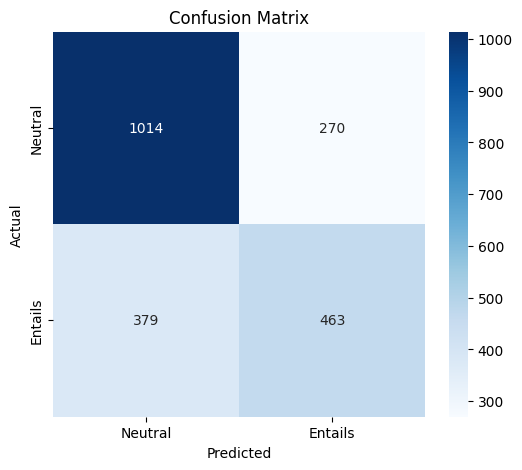

=== Classification Report ===



{'0.0': {'precision': 0.7279253409906676,
  'recall': 0.7897196261682243,
  'f1-score': 0.7575644378035113,
  'support': 1284.0},
 '1.0': {'precision': 0.6316507503410641,
  'recall': 0.5498812351543944,
  'f1-score': 0.587936507936508,
  'support': 842.0},
 'accuracy': 0.6947318908748824,
 'macro avg': {'precision': 0.6797880456658658,
  'recall': 0.6698004306613093,
  'f1-score': 0.6727504728700097,
  'support': 2126.0},
 'weighted avg': {'precision': 0.6897958935179648,
  'recall': 0.6947318908748824,
  'f1-score': 0.6903834796906153,
  'support': 2126.0}}

C:\Users\marti\AppData\Local\Temp\ipykernel_24508\1451554946.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=main_metrics, y=values, palette="viridis")


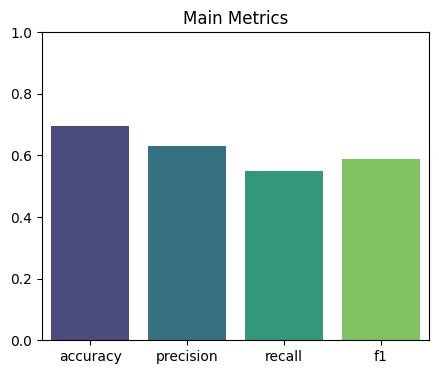

In [104]:
twin_task.visualize_metrics(twin_metrics)

### Attention Ablation Study

In [105]:
attentions = ['None','dot', 'scaled_dot', 'general', 'additive', 'cosine']

In [106]:
import torch, gc, json

results = {}
losses = {}
if False:
    for attn in attentions:
        print(f"Training with attention type: {attn}")

        ablation_model = twin_LSTM(
            input_size=embed_model.vector_size,
            hidden_size=32,
            output_size=1,
            dropout=0.5,
            bidirectional=True,
            n_layers=1,
            attn_type=attn,
        )

        optimizer = torch.optim.Adam(ablation_model.parameters(), lr=0.001,weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', patience=3, factor=0.5
            )
        
        ablation_task = Task(
            model=ablation_model,
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            save_path=f"{attn}.pth",
            optimizer=optimizer,
            scheduler=scheduler,
            loss_fn=nn.BCEWithLogitsLoss(),
            device="cuda" if torch.cuda.is_available() else "cpu",
            batch_size=48,
            weighted_sampling=False,
            forward_func=twin_forward
        )

        
        ablation_task.losses = {"train": [], "val": []}
        ablation_task.fit(epochs=50, patience=3, restore_best=True, verbose=True)

        losses[attn] = ablation_task.losses
        metrics = ablation_task.evaluate()
        print(f"Metrics for attention type {attn}: {metrics}")
        results[attn] = metrics


        del ablation_task
        torch.cuda.empty_cache()
        gc.collect()


    with open("ablation_losses.json", "w") as f:
        json.dump(losses, f, indent=4)

    with open("ablation_results.json", "w") as f:
        json.dump(results, f, indent=4)

In [2]:
import os, json
if os.path.exists("ablation_results.json"):
    with open("ablation_results.json", "r") as f:
        results = json.load(f)

In [3]:
for attn, metrics in results.items():
    print(f"Attention: {attn}, Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")

Attention: None, Accuracy: 0.6496, F1: 0.3516
Attention: dot, Accuracy: 0.7093, F1: 0.5767
Attention: scaled_dot, Accuracy: 0.7065, F1: 0.5959
Attention: general, Accuracy: 0.6919, F1: 0.5727
Attention: additive, Accuracy: 0.6957, F1: 0.5855
Attention: cosine, Accuracy: 0.7131, F1: 0.5982


In [4]:
for attn, metrics in results.items():
    print(f"Attn: {attn}")
    display(metrics['accuracy'])

Attn: None


0.6495766698024459

Attn: dot


0.70931326434619

Attn: scaled_dot


...

0.6919096895578551

Attn: additive


0.6956726246472248

Attn: cosine


0.7130761994355598

# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## Bert

In [ ]:
bert_model = BERTNet(
    n_segments=2,
    max_len=20,
    embed_dim=300,
    n_layers=2,
    attn_heads=4,
    dropout=0.3,
    vocab_size=VOCAB_SIZE
)


def bert_forward(batch, model, device, max_len=20):
    p_ids = batch["p_ids"]
    h_ids = batch["h_ids"]
    p_postag = batch["p_postag"]
    h_postag = batch["h_postag"]

    x, seg, attn_mask, pos_ids = format_ids(
        p_ids, h_ids,
        p_postags=p_postag,
        h_postags=h_postag,
        max_len=max_len
    )


    x = x.to(device)
    seg = seg.to(device)
    attn_mask = attn_mask.to(device)
    pos_ids = pos_ids.to(device)

    outputs = model(x, seg, pos_ids, attention_mask=attn_mask)
    return outputs


bert_model.load_state_dict(torch.load("bert_nli.pth"))

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
) 

bert_task = Task(
    model=bert_model,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    save_path="bert_nli.pth",
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=nn.BCEWithLogitsLoss(),
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=64,
    weighted_sampling=True,
    forward_func=bert_forward
)

Evaluating: 100%|██████████| 34/34 [00:01<00:00, 25.16it/s]


=== Overall Metrics ===
Accuracy  : 0.4831
Precision : 0.4154
Recall    : 0.7494
F1        : 0.5345




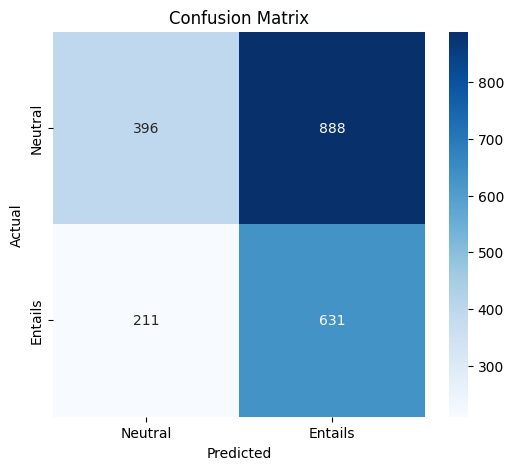

=== Classification Report ===



{'0.0': {'precision': 0.6523887973640856,
  'recall': 0.308411214953271,
  'f1-score': 0.4188260179799048,
  'support': 1284.0},
 '1.0': {'precision': 0.41540487162606976,
  'recall': 0.7494061757719715,
  'f1-score': 0.5345192714951292,
  'support': 842.0},
 'accuracy': 0.4830667920978363,
 'macro avg': {'precision': 0.5338968344950776,
  'recall': 0.5289086953626213,
  'f1-score': 0.476672644737517,
  'support': 2126.0},
 'weighted avg': {'precision': 0.5585315699551442,
  'recall': 0.4830667920978363,
  'f1-score': 0.464646205872576,
  'support': 2126.0}}

C:\Users\marti\AppData\Local\Temp\ipykernel_24508\1451554946.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=main_metrics, y=values, palette="viridis")


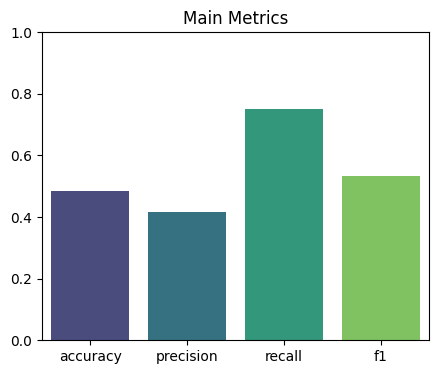

In [48]:
metrics = bert_task.evaluate()
bert_task.visualize_metrics(metrics)

## C-LSTM 

In [ ]:
clstm = CLSTM(
    embed_dim=embed_model.vector_size,
    hidden_size=32
)

def clstm_forward(batch, model, device):
    p_embed = batch["p_embed"].to(device)
    h_embed = batch["h_embed"].to(device)

    p_lengths = batch["p_lengths"]
    h_lengths = batch["h_lengths"]
    premise_postag = batch["p_postag"]
    hypothesis_postag = batch["h_postag"]

    outputs = model(p_embed, h_embed, p_lengths, h_lengths, premise_postag, hypothesis_postag)
    return outputs


optimizer = torch.optim.Adam(clstm.parameters(), lr=0.001,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

cnn_task = Task(
    model=clstm,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    save_path="clstm.pth",
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=nn.BCEWithLogitsLoss(),
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=48,
    weighted_sampling=True,
    forward_func=clstm_forward
)

Evaluating: 100%|██████████| 45/45 [00:01<00:00, 35.69it/s]


=== Overall Metrics ===
Accuracy  : 0.6538
Precision : 0.5551
Recall    : 0.6342
F1        : 0.5920




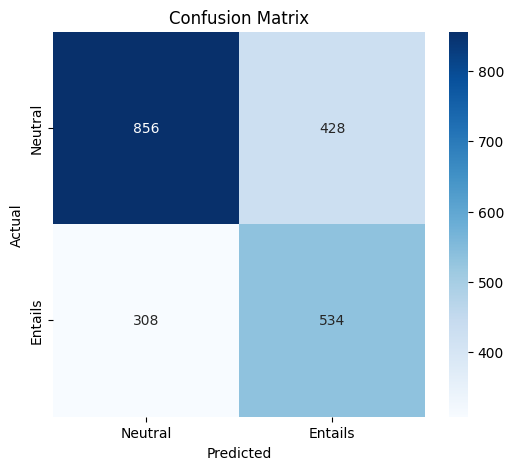

=== Classification Report ===



{'0.0': {'precision': 0.7353951890034365,
  'recall': 0.6666666666666666,
  'f1-score': 0.6993464052287581,
  'support': 1284.0},
 '1.0': {'precision': 0.5550935550935551,
  'recall': 0.6342042755344418,
  'f1-score': 0.5920177383592018,
  'support': 842.0},
 'accuracy': 0.6538099717779868,
 'macro avg': {'precision': 0.6452443720484957,
  'recall': 0.6504354711005542,
  'f1-score': 0.64568207179398,
  'support': 2126.0},
 'weighted avg': {'precision': 0.6639869219516397,
  'recall': 0.6538099717779868,
  'f1-score': 0.6568390028279273,
  'support': 2126.0}}

C:\Users\marti\AppData\Local\Temp\ipykernel_24508\1451554946.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=main_metrics, y=values, palette="viridis")


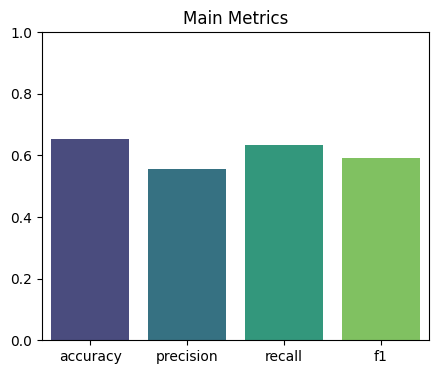

In [50]:
metrics = cnn_task.evaluate()
cnn_task.visualize_metrics(metrics)

## LSTM Enc-Dec

In [51]:
postag_vocab_size = len(postag2idx) 
postag_emb_dim = 32              

twin_model = twin_LSTM(
    input_size=embed_model.vector_size,
    hidden_size=128,
    output_size=1,
    dropout=0.5,
    bidirectional=True,
    n_layers=2,
    postag_vocab_size=None,
    postag_emb_dim=postag_emb_dim,
    attn_type="scaled_dot"
)

twin_model.load_state_dict(torch.load("twin_model.pth"))

def twin_forward(batch, model, device):
    p_embed = batch["p_embed"].to(device)
    h_embed = batch["h_embed"].to(device)

    p_lengths = batch["p_lengths"]
    h_lengths = batch["h_lengths"]
    premise_postag = batch["p_postag"]
    hypothesis_postag = batch["h_postag"]

    outputs = model(p_embed, h_embed, p_lengths, h_lengths, premise_postag, hypothesis_postag)
    return outputs
optimizer = torch.optim.Adam(twin_model.parameters(), lr=0.001,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)
twin_task = Task(
    model=twin_model,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    save_path="twin_model.pth",
    optimizer=torch.optim.Adam(twin_model.parameters(), lr=0.001),
    scheduler=scheduler,
    loss_fn=nn.BCEWithLogitsLoss(),
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=64,
    weighted_sampling=True,
    forward_func=twin_forward
)


Evaluating: 100%|██████████| 34/34 [00:01<00:00, 32.86it/s]


=== Overall Metrics ===
Accuracy  : 0.6599
Precision : 0.5750
Recall    : 0.5416
F1        : 0.5578




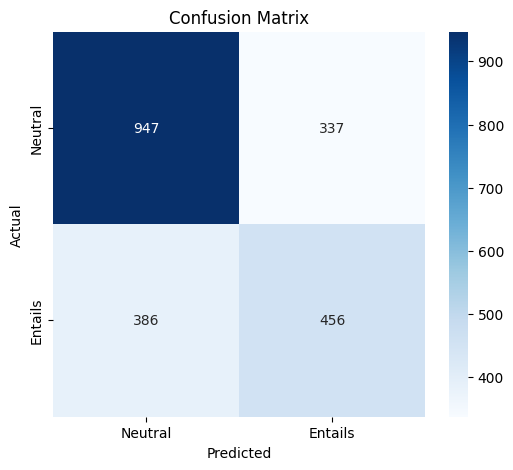

=== Classification Report ===



{'0.0': {'precision': 0.7104276069017255,
  'recall': 0.7375389408099688,
  'f1-score': 0.7237294612151318,
  'support': 1284.0},
 '1.0': {'precision': 0.575031525851198,
  'recall': 0.5415676959619953,
  'f1-score': 0.5577981651376147,
  'support': 842.0},
 'accuracy': 0.6599247412982127,
 'macro avg': {'precision': 0.6427295663764617,
  'recall': 0.6395533183859821,
  'f1-score': 0.6407638131763733,
  'support': 2126.0},
 'weighted avg': {'precision': 0.65680413547908,
  'recall': 0.6599247412982127,
  'f1-score': 0.6580125509153814,
  'support': 2126.0}}

C:\Users\marti\AppData\Local\Temp\ipykernel_24508\1451554946.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=main_metrics, y=values, palette="viridis")


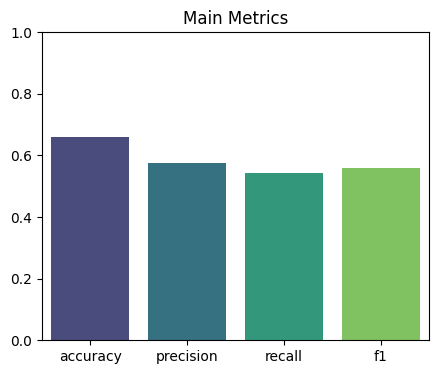

In [52]:
metrics = twin_task.evaluate()
twin_task.visualize_metrics(metrics)

In [53]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_attention(model, dataloader, df, device=None, batch_idx=0, sample_idx=0):
    """
    Visualize cross/self-attention for a single sample from a DataLoader.
    
    Args:
        model: The trained twin model with attention.
        dataloader: DataLoader for the test set.
        df: Original DataFrame with tokenized sentences.
        device: torch device
        batch_idx: Which batch to take from DataLoader
        sample_idx: Which sample in the batch to visualize
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model.eval()
    
    # Get the chosen batch
    for i, batch in enumerate(dataloader):
        if i == batch_idx:
            sample_batch = batch
            break
    
    # Move embeddings and postags to device
    p_embed = sample_batch["p_embed"].to(device)
    h_embed = sample_batch["h_embed"].to(device)
    p_postag = sample_batch["p_postag"].to(device)
    h_postag = sample_batch["h_postag"].to(device)
    p_lengths = sample_batch["p_lengths"]
    h_lengths = sample_batch["h_lengths"]
    
    # Forward pass to get attention
    with torch.no_grad():
        outputs, attn_weights, mask = model(
            p_embed, h_embed, 
            p_lengths, h_lengths, 
            p_postag, h_postag, 
            return_attn=True  # your model must support this
        )
    
    # Extract sample from batch
    sample_attn = attn_weights[sample_idx]  # shape: [L_h, L_p]
    sample_len_p = p_lengths[sample_idx]
    sample_len_h = h_lengths[sample_idx]
    
    # Slice out real tokens (remove padding)
    sample_attn = sample_attn[:sample_len_h, :sample_len_p].cpu().numpy()
    
    # Map batch sample to original DataFrame
    global_idx = dataloader.batch_size * batch_idx + sample_idx
    premise_tokens = df["premise"].iloc[global_idx]
    hypothesis_tokens = df["hypothesis"].iloc[global_idx]
    # Heatmap visualization
    plt.figure(figsize=(24, 6))
    sns.heatmap(sample_attn, xticklabels=premise_tokens, yticklabels=hypothesis_tokens, cmap='viridis')
    plt.xlabel("Premise Tokens")
    plt.ylabel("Hypothesis Tokens")
    plt.title(f"Attention Visualization: Sample {global_idx}")
    plt.xticks(rotation=0)  # x-axis tokens horizontal
    plt.yticks(rotation=0)  # y-axis tokens horizontal
    plt.gca().invert_yaxis()  # hypothesis top-to-bottom
    plt.show()

    
    # Optional: print averaged attention per premise token
    avg_attn = sample_attn.mean(0)
    print("\nAverage attention per premise token:")
    for token, weight in zip(premise_tokens, avg_attn):
        print(f"{token}: {weight:.2f}")




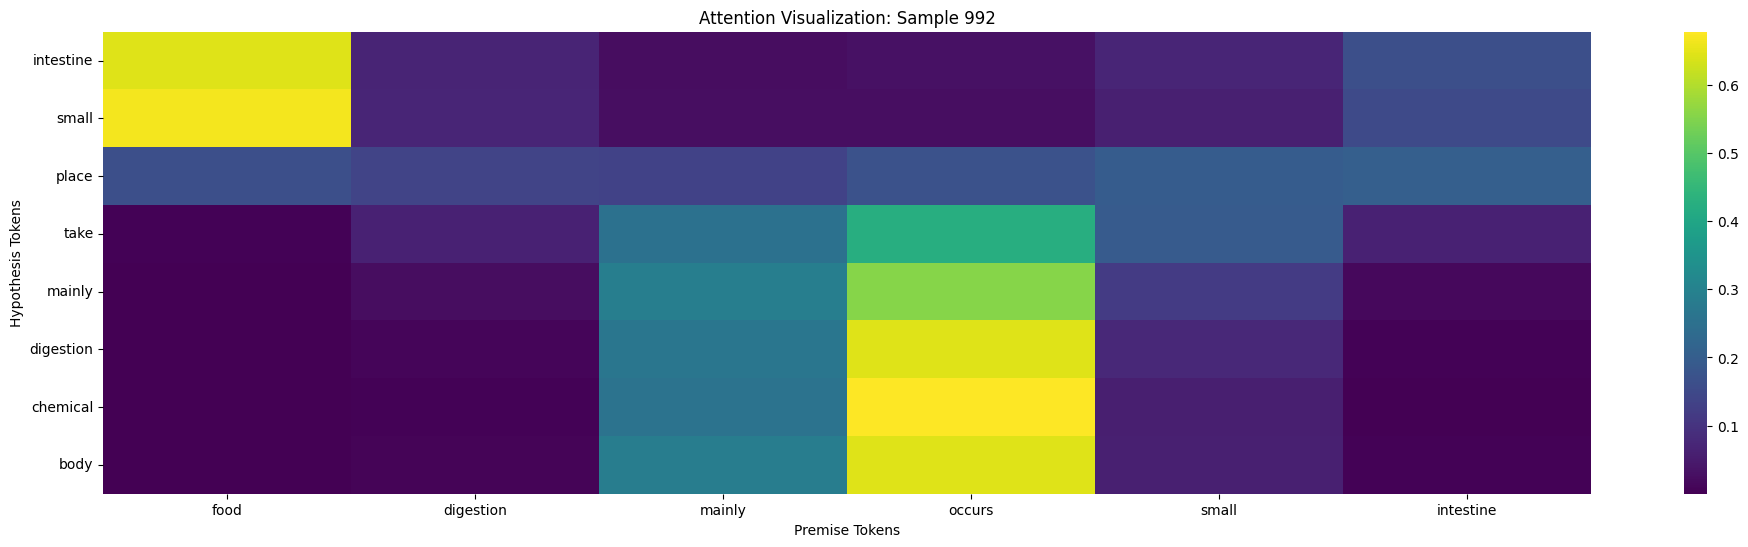


Average attention per premise token:
food: 0.18
digestion: 0.05
mainly: 0.19
occurs: 0.40
small: 0.10
intestine: 0.08


In [132]:
visualize_attention(
    model=twin_task.model,
    dataloader=twin_task.test_loader,
    df=twin_task.test_df,
    batch_idx=np.random.randint(0,len(twin_task.test_loader)),
    sample_idx=np.random.randint(0,twin_task.batch_size)
)


## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*